# Here we fit using pytorch lots of GLMs at once

Setup:
* q:
* p:
* n: 

* q: number of covariates
* p: number of observations per glm
* n: number of glm

* covariates X of size pxq is shared across all GLMs
* responses Y of size px1 is different for each GLM

using LBFGs and massive vectorization.

Choose one glm of your choice.

In [1]:
import torch

def poisson_glm_fisher_scoring(X, Y, iters=4, lr=0.2):
    """
    Ultra-fast approximate Poisson GLM solver.
    
    X: [N, P]  design matrix
    Y: [N, K]  responses for K GLMs
    iters:     number of Fisher scoring iterations
    lr:        step size for updates
    
    Returns:
        B: [P, K] estimated coefficients
    """

    device = X.device
    N, P = X.shape
    K = Y.shape[1]

    # Precompute shared Hessian H = X^T X   (P×P)
    H = X.T @ X
    H_inv = torch.linalg.inv(H)  # cheap because P ≤ 50

    # Initialize beta
    B = torch.zeros(P, K, device=device)

    for t in range(iters):

        # 1. Linear predictor and rate
        ETA = X @ B
        ETA = torch.clamp(ETA, -15, 15)     # stabilizer
        LAM = torch.exp(ETA)

        # 2. Gradient for each GLM: g_k = X^T (Y_k - lambda_k)
        R = Y - LAM                         # [N, K]
        G = X.T @ R                         # [P, K]

        # 3. Newton update using shared Hessian inverse
        # ΔB = H^{-1} G
        delta_B = H_inv @ G                 # [P, K]

        # 4. Update with step-size damping
        B = B + lr * delta_B

    return B


In [4]:
# Synthetic test
torch.manual_seed(0)

N = 600000
P = 20
K = 1000

X = torch.randn(N, P)
B_true = torch.randn(P, K) * 0.2

ETA = X @ B_true
LAM = torch.exp(torch.clamp(ETA, -6, 6))
Y = torch.poisson(LAM)

# Solve
B_est = poisson_glm_fisher_scoring(X, Y, iters=4, lr=0.25)

print("Mean abs error:", (B_est - B_true).abs().mean().item())


Mean abs error: 0.012136929668486118


In [6]:
import torch
import time

# ============================================================
# 1. Generate synthetic Gaussian GLM data
# ============================================================

def generate_gaussian_problem(N=600_000, P=20, K=1000):
    torch.manual_seed(0)
    X = torch.randn(N, P)

    B_true = torch.randn(P, K) * 0.3
    noise = torch.randn(N, K) * 0.1

    Y = X @ B_true + noise
    return X, Y, B_true


# ============================================================
# 2. Solve all K Gaussian GLMs in closed form
# ============================================================

def gaussian_glm_closed_form(X, Y):
    """
    Solve 1000 Gaussian GLMs with design matrix X in a single step.
    Returns B: [P, K]
    """
    # Compute X^T X  [P × P]
    XtX = X.T @ X

    # Compute X^T Y  [P × K]
    XtY = X.T @ Y

    # Solve XtX B = XtY
    B = torch.linalg.solve(XtX, XtY)

    return B


# ============================================================
# 3. Full example
# ============================================================

if __name__ == "__main__":
    N = 600_000
    P = 20
    K = 1000

    print("Generating data...")
    X, Y, B_true = generate_gaussian_problem(N, P, K)

    print("Solving Gaussian GLMs...")
    t0 = time.time()

    B_est = gaussian_glm_closed_form(X, Y)

    t1 = time.time()
    print(f"Total solve time: {t1 - t0:.4f} seconds")

    err = (B_est - B_true).abs().mean().item()
    print("Mean abs error:", err)

    print("\nTrue beta for first GLM:", B_true[:, 0])
    print("Estimated beta:", B_est[:, 0])


Generating data...
Solving Gaussian GLMs...
Total solve time: 0.1048 seconds
Mean abs error: 0.00010653823846951127

True beta for first GLM: tensor([ 0.2740,  0.1858,  0.0028, -0.0065, -0.6147,  0.1439, -0.0697, -0.0176,
         0.0625, -0.0351,  0.3093, -0.0111,  0.2410,  0.1904,  0.3582,  0.3494,
        -0.2565,  0.1707, -0.0393,  0.2167])
Estimated beta: tensor([ 0.2740,  0.1857,  0.0028, -0.0064, -0.6147,  0.1440, -0.0697, -0.0175,
         0.0625, -0.0348,  0.3094, -0.0112,  0.2410,  0.1904,  0.3581,  0.3496,
        -0.2566,  0.1708, -0.0393,  0.2165])


Generating data...
Solving approximate Poisson...
Total solve time: 0.028 seconds
Mean absolute error across ALL GLMs: 0.12004798650741577


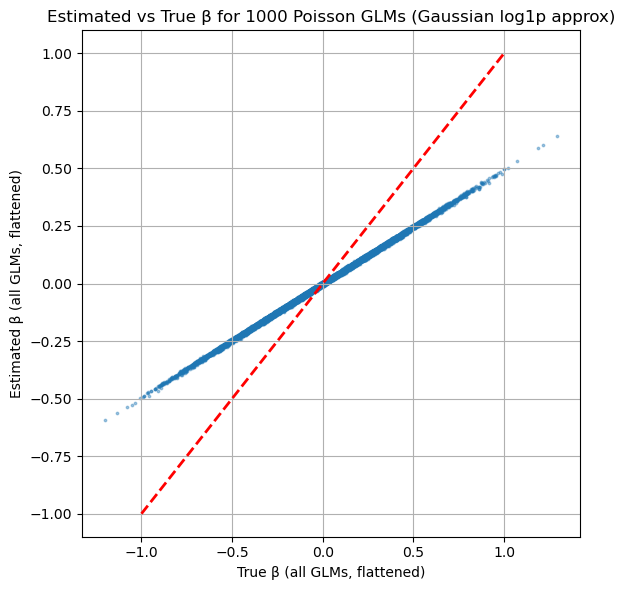

Correlation true vs estimated: 0.9996679425239563


In [10]:
import torch
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. Generate synthetic Poisson-GLM data
# ============================================================
def generate_poisson_problem(N=600_000, P=20, K=1000):
    torch.manual_seed(0)

    # Shared design matrix
    X = torch.randn(N, P)

    # True coefficients B_true: [P, K]
    B_true = torch.randn(P, K) * 0.3

    ETA = X @ B_true
    ETA = torch.clamp(ETA, -6, 6)

    LAM = torch.exp(ETA)
    Y = torch.poisson(LAM)

    return X, Y, B_true


# ============================================================
# 2. Very fast Poisson approximation via log(y+1) Gaussian GLM
# ============================================================
def fast_poisson_log_approx(X, Y):
    Z = torch.log1p(Y)      # [N, K]
    XtX = X.T @ X           # [P, P]
    XtZ = X.T @ Z           # [P, K]
    B_est = torch.linalg.solve(XtX, XtZ)
    return B_est


# ============================================================
# 3. Main experiment with correct plotting
# ============================================================
if __name__ == "__main__":
    N = 60_000
    P = 20
    K = 1000

    print("Generating data...")
    X, Y, B_true = generate_poisson_problem(N, P, K)

    print("Solving approximate Poisson...")
    t0 = time.time()
    B_est = fast_poisson_log_approx(X, Y)
    t1 = time.time()

    print(f"Total solve time: {t1 - t0:.3f} seconds")

    # Compute overall parameter error
    mae = (B_est - B_true).abs().mean().item()
    print("Mean absolute error across ALL GLMs:", mae)

    # ============================================================
    # Correct plotting: flatten ALL coefficients across K models
    # ============================================================
    true_flat = B_true.flatten().cpu().numpy()
    est_flat  = B_est.flatten().cpu().numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(true_flat, est_flat, s=3, alpha=0.4)
    plt.plot([-1,1], [-1,1], 'r--', lw=2)
    plt.xlabel("True β (all GLMs, flattened)")
    plt.ylabel("Estimated β (all GLMs, flattened)")
    plt.title(f"Estimated vs True β for {K} Poisson GLMs (Gaussian log1p approx)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Correlation
    corr = torch.corrcoef(torch.tensor([true_flat, est_flat]))[0,1].item()
    print("Correlation true vs estimated:", corr)


In [8]:
b_true.shape

torch.Size([20])